In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('mymoviedb.csv', lineterminator = '\n')

In [5]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [7]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


~ Exploration summary

-we have a dataframe consisting of 9827 and 9 columns
-our dataset looks a bit tudy wuth no NaNs nor duplicate values 
-Release_Date column needs to be casted into date time and to extract only the year value
-Overview,Original_Langauge and Poster-Url wouldn't be so useful during analysis ,so we'll drop time
-there is noticable outliers in Popularity column
-Vote_Average better to be categorised for proper analysis
-Genre column has comma separated values and white spaces that needs to be handled and casted into category.

In [11]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


In [12]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [13]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Dropping the columns


In [14]:
cols = ['Overview','Original_Language','Poster_Url']

In [15]:
df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [29]:
df['Vote_Average'].value_counts()

Vote_Average
6.4     435
6.3     429
6.5     427
6.8     423
6.7     420
       ... 
2.2       1
9.2       1
1.5       1
3.1       1
10.0      1
Name: count, Length: 74, dtype: int64

In [34]:
def categorize_col(df, col, labels):
    desc = df[col].describe()

    edges = [
        desc['min'],
        desc['25%'],
        desc['50%'],
        desc['75%'],
        desc['max']
    ]

    df[col] = pd.cut(
        df[col],
        bins=edges,
        labels=labels,
        duplicates='drop',
        include_lowest=True
    )

    return df

In [35]:
labels = ['Low', 'Medium', 'High', 'Very High']

df = categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].head()

0    Very High
1    Very High
2       Medium
3    Very High
4         High
Name: Vote_Average, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']

In [36]:
df['Vote_Average'].value_counts()

Vote_Average
Low          2567
Very High    2450
High         2412
Medium       2398
Name: count, dtype: int64

In [37]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very High,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Very High,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Medium,Thriller
3,2021,Encanto,2402.201,5076,Very High,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,High,"Action, Adventure, Thriller, War"


In [39]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Science Fiction
3,2022,The Batman,3827.658,1151,Very High,Crime
4,2022,The Batman,3827.658,1151,Very High,Mystery


In [40]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25793 non-null  int32   
 1   Title         25793 non-null  object  
 2   Popularity    25793 non-null  float64 
 3   Vote_Count    25793 non-null  int64   
 4   Vote_Average  25793 non-null  category
 5   Genre         25793 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.7+ KB


In [42]:
df.nunique()

Release_Date     102
Title           9513
Popularity      8160
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

In [43]:
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Science Fiction
3,2022,The Batman,3827.658,1151,Very High,Crime
4,2022,The Batman,3827.658,1151,Very High,Mystery


# Data Visualization

In [ ]:
sns.style('Whitegrid')

# What is the most frequent genre of movies released on Netflix?

In [45]:
df['Genre'].describe()

count     25793
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

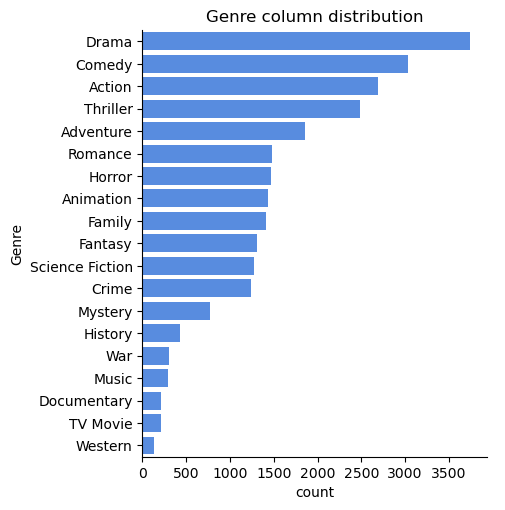

In [47]:
sns.catplot(y = 'Genre', data = df, kind = 'count',
            order = df['Genre'].value_counts().index,
            color = '#4287f5')
plt.title("Genre column distribution")
plt.show()

# what movie got the highest popularity? what's its genre?

In [51]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Adventure


In [52]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Very High,Science Fiction


# what movie got the lowest popularity? what's its genre?

In [53]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25787,2021,The United States vs. Billie Holiday,13.354,152,High,Music
25788,2021,The United States vs. Billie Holiday,13.354,152,High,Drama
25789,2021,The United States vs. Billie Holiday,13.354,152,High,History
25790,1984,Threads,13.354,186,Very High,War
25791,1984,Threads,13.354,186,Very High,Drama
25792,1984,Threads,13.354,186,Very High,Science Fiction


# Which year has the most filmmed movies?

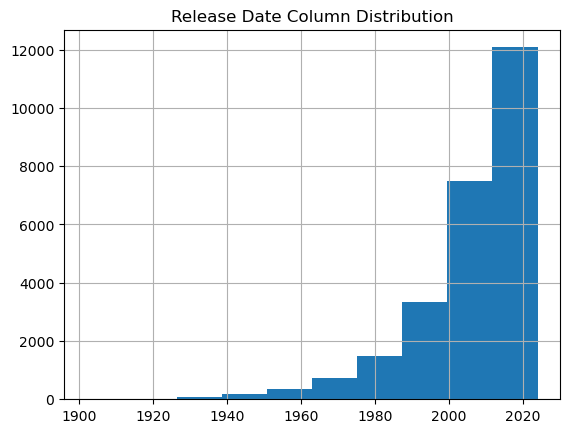

In [55]:
df['Release_Date'].hist()
plt.title("Release Date Column Distribution")
plt.show()